In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import pickle

In [2]:
df = pd.read_csv('dataset/loan_data.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
print("Shape:", df.shape)
df.info()
print("\nMissing Values:\n", df.isnull().sum())

Shape: (614, 13)
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB

Missing Values:
 Loan_ID               0
Gender               13
Married               3
Dependents          

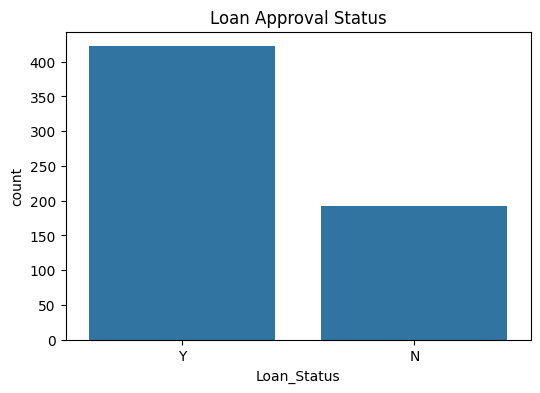

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Approval Status')
plt.show()

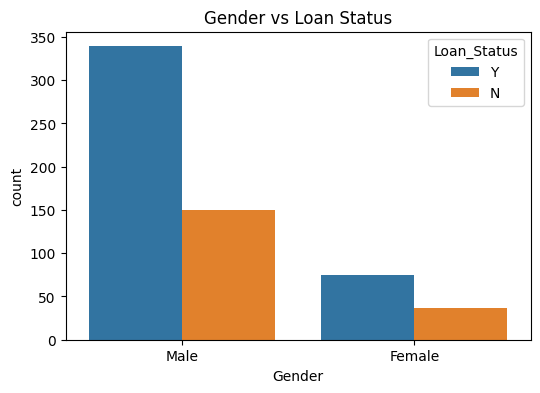

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Loan_Status', data=df)
plt.title('Gender vs Loan Status')
plt.show()

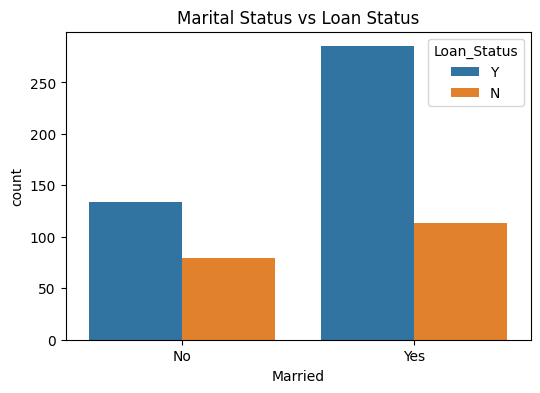

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Married', hue='Loan_Status', data=df)
plt.title('Marital Status vs Loan Status')
plt.show()

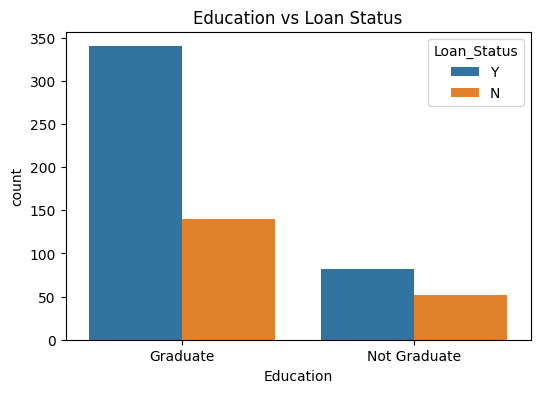

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title('Education vs Loan Status')
plt.show()

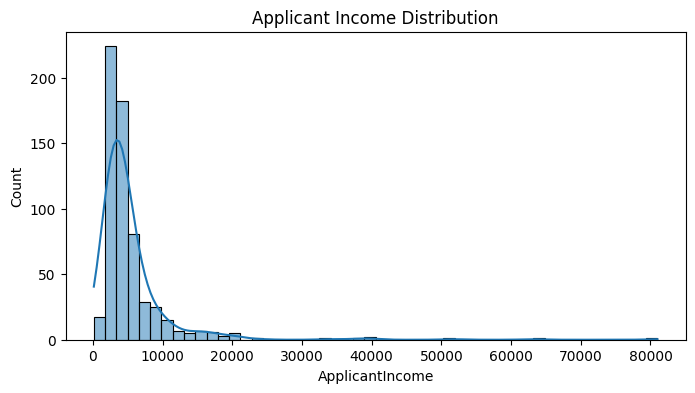

In [8]:
plt.figure(figsize=(8,4))
sns.histplot(df['ApplicantIncome'], bins=50, kde=True)
plt.title('Applicant Income Distribution')
plt.show()

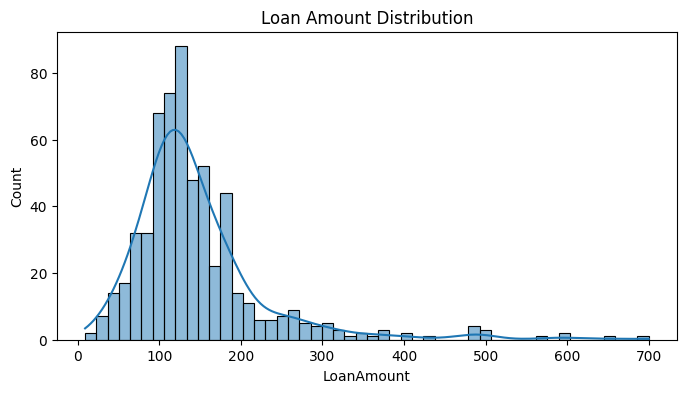

In [9]:
plt.figure(figsize=(8,4))
sns.histplot(df['LoanAmount'], bins=50, kde=True)
plt.title('Loan Amount Distribution')
plt.show()

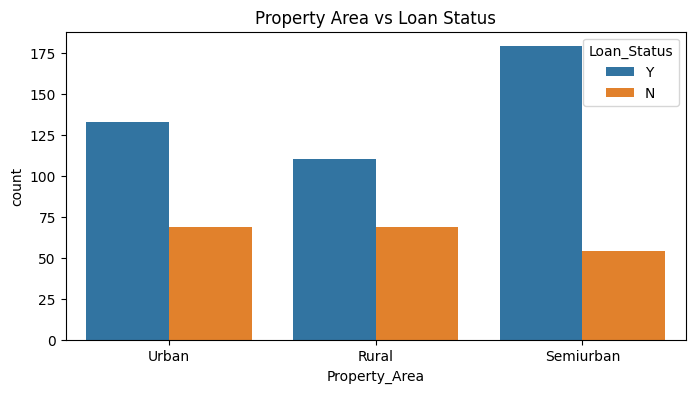

In [10]:
plt.figure(figsize=(8,4))
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title('Property Area vs Loan Status')
plt.show()

In [11]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])
 
print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [12]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]
 
print("Shape before outlier removal:", df.shape)
df = remove_outliers_iqr(df, 'ApplicantIncome')
df = remove_outliers_iqr(df, 'LoanAmount')
df = df.reset_index(drop=True)
print("Shape after outlier removal:", df.shape)


Shape before outlier removal: (614, 13)
Shape after outlier removal: (534, 13)


In [13]:
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
encoders = {}
 
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")
 
df['Loan_Status'] = LabelEncoder().fit_transform(df['Loan_Status'])
 
with open('models/encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)
 
print("\nEncoders saved!")

Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Married: {'No': np.int64(0), 'Yes': np.int64(1)}
Dependents: {'0': np.int64(0), '1': np.int64(1), '2': np.int64(2), '3+': np.int64(3)}
Education: {'Graduate': np.int64(0), 'Not Graduate': np.int64(1)}
Self_Employed: {'No': np.int64(0), 'Yes': np.int64(1)}
Property_Area: {'Rural': np.int64(0), 'Semiurban': np.int64(1), 'Urban': np.int64(2)}

Encoders saved!


In [14]:
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df['Loan_Status']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(427, 11) (107, 11)


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
 
print("Feature scaling done and scaler saved!")


Feature scaling done and scaler saved!


In [16]:
print("Before SMOTE:", y_train.value_counts().to_dict())
 
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
 
print("After SMOTE:", y_train_balanced.value_counts().to_dict())

Before SMOTE: {1: 297, 0: 130}
After SMOTE: {1: 297, 0: 297}


In [17]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_balanced, y_train_balanced)
print(f"Decision Tree - Train: {accuracy_score(y_train_balanced, dt.predict(X_train_balanced)):.3f}, Test: {accuracy_score(y_test, dt.predict(X_test_scaled)):.3f}")
 
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_balanced, y_train_balanced)
print(f"Random Forest - Train: {accuracy_score(y_train_balanced, rf.predict(X_train_balanced)):.3f}, Test: {accuracy_score(y_test, rf.predict(X_test_scaled)):.3f}")
 
knn = KNeighborsClassifier()
knn.fit(X_train_balanced, y_train_balanced)
print(f"KNN - Train: {accuracy_score(y_train_balanced, knn.predict(X_train_balanced)):.3f}, Test: {accuracy_score(y_test, knn.predict(X_test_scaled)):.3f}")
 
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_balanced, y_train_balanced)
print(f"XGBoost - Train: {accuracy_score(y_train_balanced, xgb.predict(X_train_balanced)):.3f}, Test: {accuracy_score(y_test, xgb.predict(X_test_scaled)):.3f}")

Decision Tree - Train: 1.000, Test: 0.748
Random Forest - Train: 1.000, Test: 0.832
KNN - Train: 0.859, Test: 0.710
XGBoost - Train: 1.000, Test: 0.822


Confusion Matrix:
[[18 15]
 [ 4 70]]


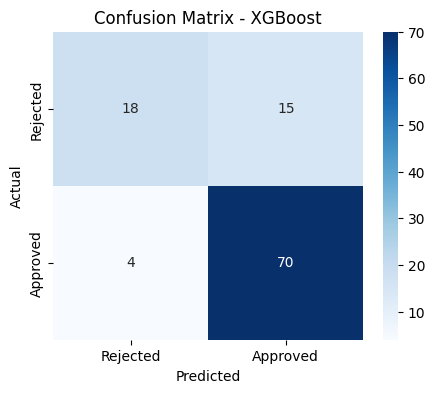


Classification Report:
              precision    recall  f1-score   support

    Rejected       0.82      0.55      0.65        33
    Approved       0.82      0.95      0.88        74

    accuracy                           0.82       107
   macro avg       0.82      0.75      0.77       107
weighted avg       0.82      0.82      0.81       107



In [18]:
y_pred_xgb = xgb.predict(X_test_scaled)
 
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_xgb)
print(cm)
 
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Rejected','Approved'], yticklabels=['Rejected','Approved'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()
 
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Rejected','Approved']))

In [19]:
with open('models/rdf.pkl', 'wb') as f:
    pickle.dump(xgb, f)
 
print("Model saved successfully as rdf.pkl!")

Model saved successfully as rdf.pkl!


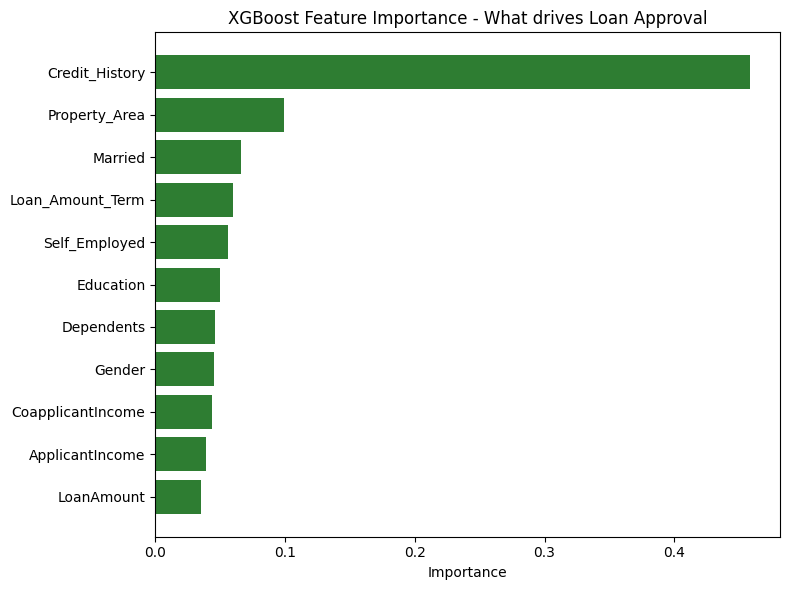

              Feature  Importance
9      Credit_History    0.458530
10      Property_Area    0.099307
1             Married    0.066222
8    Loan_Amount_Term    0.059997
4       Self_Employed    0.056385
3           Education    0.049603
2          Dependents    0.046097
0              Gender    0.045294
6   CoapplicantIncome    0.043522
5     ApplicantIncome    0.039429
7          LoanAmount    0.035615


In [20]:
# Feature Importance - XGBoost (shows which features influence approval/rejection most)
feature_names = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
                  'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
                  'Loan_Amount_Term', 'Credit_History', 'Property_Area']

importances = xgb.feature_importances_

feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=True)

plt.figure(figsize=(8,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#2e7d32')
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance - What drives Loan Approval')
plt.tight_layout()
plt.show()

print(feat_imp.sort_values('Importance', ascending=False))